Лабораторна робота №4 “Класифікація”

Мета роботи: ознайомитися з основами класифікації при інтелектуальному аналізі даних на прикладі реального історичного набору даних Titanic.
Навчитись будувати класифікатор на основі дерев рішень (Decision Tree), виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [34]:
df = pd.read_csv("train.csv")
print(f"Розмір датасету: {df.shape}")
df.head()

Розмір датасету: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
print("Інформація про DataFrame:")
df.info()
print("\nКількість пропусків у кожній колонці:")
print(df.isna().sum().sort_values(ascending=False))

Інформація про DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Кількість пропусків у кожній колонці:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Tick

Виводимо загальну інформацію про DataFrame — типи стовпців та кількість непустих значень. Перевіряємо наявність пропущених значень у кожній колонці. Найбільше пропусків у Cabin (687), Age (177) та Embarked (2). Колонку Cabin не використовуватимемо через велику кількість пропусків.

In [36]:
if df["Age"].isna().any():
    df["Age"] = df["Age"].fillna(df["Age"].median())

if df["Embarked"].isna().any():
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Пропуски після обробки:")
print(df[["Age", "Embarked"]].isna().sum())

Пропуски після обробки:
Age         0
Embarked    0
dtype: int64


Заповнюємо пропущені значення: для Age використовуємо медіану, оскільки вік може містити викиди, а медіана стійка до них; для Embarked — моду (найпоширеніший порт посадки — "S"). Після обробки пропуски у цих колонках відсутні.

In [37]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

model_df = df[features + [target]].copy()
model_df = pd.get_dummies(model_df, columns=["Sex", "Embarked"], drop_first=True)

print("Ознаки після кодування:")
print(model_df.columns.tolist())
model_df.head()

Ознаки після кодування:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


Обираємо ознаки для моделі та виконуємо кодування категоріальних змінних. Sex і Embarked перетворюємо у числовий формат за допомогою One-Hot Encoding. Параметр drop_first=True прибирає одну з фіктивних змінних для уникнення мультиколінеарності.

In [38]:
X = model_df.drop(columns=[target])
y = model_df[target]

print(f"Розмір X: {X.shape}")
print(f"Розмір y: {y.shape}")

Розмір X: (891, 8)
Розмір y: (891,)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (712, 8)
X_test:  (179, 8)
y_train: (712,)
y_test:  (179,)


Ділимо дані на навчальну (80%) і тестову (20%) вибірки. Параметр stratify=y забезпечує однаковий розподіл класів у обох вибірках — це важливо при незбалансованих даних. random_state=42 — для відтворюваності результату.

In [40]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42,
)

dt_model.fit(X_train, y_train)
print("Модель успішно навчено.")

Модель успішно навчено.


Навчаємо модель дерева рішень. Параметри: criterion='gini' — критерій розбиття вузлів (індекс Джині вимірює ступінь "нечистоти" вузла); max_depth=4 — обмежуємо глибину дерева для запобігання перенавчанню; random_state=42 — для відтворюваності.

In [41]:
y_pred = dt_model.predict(X_test)

print(f"Глибина дерева: {dt_model.get_depth()}")
print(f"Кількість вузлів: {dt_model.tree_.node_count}")
print("Перші 10 прогнозів:", y_pred[:10])

Глибина дерева: 4
Кількість вузлів: 29
Перші 10 прогнозів: [0 0 0 0 1 0 1 0 0 0]


Отримуємо прогнози моделі на тестовій вибірці. Глибина дерева — 4 (як задано), кількість вузлів — 29. Виводимо перші 10 прогнозів для попередньої перевірки роботи моделі.

In [42]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7877
Precision: 0.8444
Recall:    0.5507
F1-score:  0.6667


Обчислюємо основні метрики якості класифікації:

- Accuracy — частка правильно класифікованих об'єктів серед усіх
- Precision — серед усіх передбачених позитивів, скільки є справжніми
- Recall — серед усіх реальних позитивів, скільки модель знайшла
- F1-score — гармонійне середнє між Precision і Recall

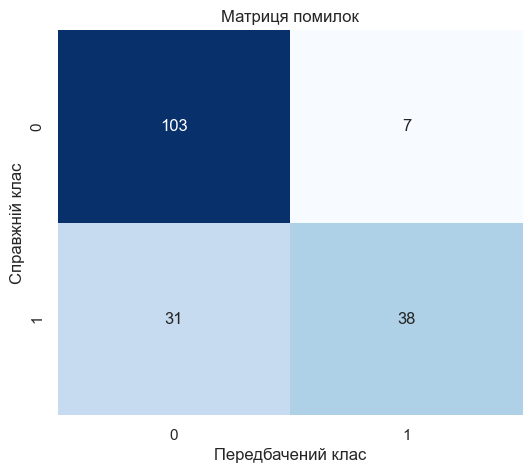

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Матриця помилок")
plt.xlabel("Передбачений клас")
plt.ylabel("Справжній клас")
plt.show()

Будуємо матрицю помилок. По рядках — справжні класи, по стовпцях — передбачені. Діагональні елементи (TN і TP) — правильні класифікації, позадіагональні (FP і FN) — помилки моделі. Чим більші числа на діагоналі, тим краще модель.

In [44]:
print(classification_report(y_test, y_pred, digits=4, target_names=["Не вижив", "Вижив"]))

              precision    recall  f1-score   support

    Не вижив     0.7687    0.9364    0.8443       110
       Вижив     0.8444    0.5507    0.6667        69

    accuracy                         0.7877       179
   macro avg     0.8066    0.7435    0.7555       179
weighted avg     0.7979    0.7877    0.7758       179



Детальний звіт по кожному класу окремо. Модель краще ідентифікує клас "Не вижив" (вищий Recall ~94%), ніж клас "Вижив" (~55%), що пов'язано з незбалансованістю класів: у тестовій вибірці більше пасажирів, що не вижили.

In [46]:
test_balance = y_test.value_counts().sort_index()
test_ratio = (y_test.value_counts(normalize=True).sort_index() * 100).round(2)

print("Кількість об'єктів за класами (тест):")
print(test_balance)
print("\nЧастка класів у тесті (%):")
print(test_ratio)

Кількість об'єктів за класами (тест):
Survived
0    110
1     69
Name: count, dtype: int64

Частка класів у тесті (%):
Survived
0    61.45
1    38.55
Name: proportion, dtype: float64


Аналізуємо баланс класів у тестовій вибірці. Клас 0 ("Не вижив") складає ~61%, клас 1 ("Вижив") — ~39%. При такому незбалансованому розподілі метрики Precision, Recall та F1-score є більш інформативними, ніж Accuracy, оскільки висока Accuracy може досягатись навіть при поганій роботі з меншим класом.

Важливість ознак:
Sex_male      0.576297
Pclass        0.195920
Age           0.106957
Fare          0.063141
Embarked_S    0.037198
SibSp         0.012109
Parch         0.008377
Embarked_Q    0.000000
dtype: float64


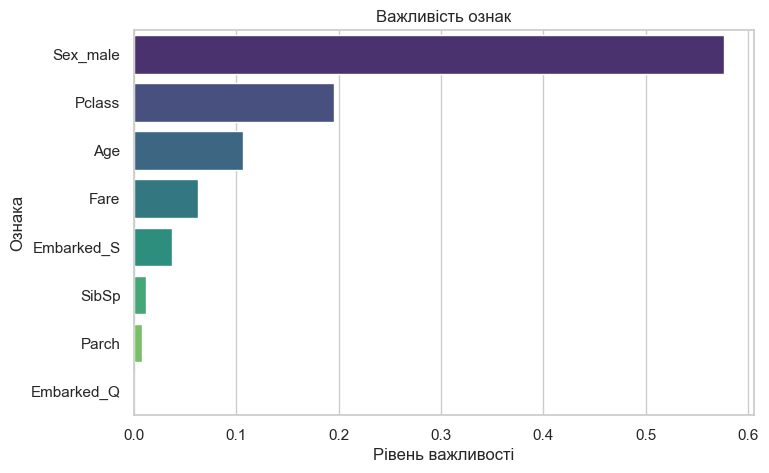

In [47]:
feature_importance = pd.Series(
    dt_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Важливість ознак:")
print(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index,
    hue=feature_importance.index,
    palette="viridis",
    legend=False,
)
plt.title("Важливість ознак")
plt.xlabel("Рівень важливості")
plt.ylabel("Ознака")
plt.show()

Відображаємо важливість ознак, яку автоматично обчислює дерево рішень на основі зменшення індексу Джині. Найважливіша ознака — Sex_male (~57%): стать є головним чинником виживання. Далі — Pclass (~20%) і Age (~11%). Ознаки Embarked_Q і Parch мають мінімальний вплив на прогноз.

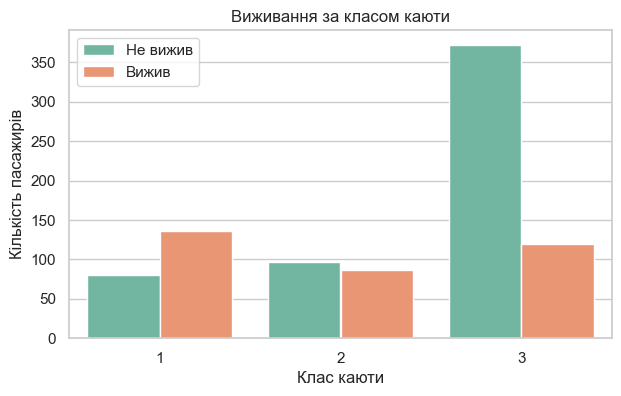

In [50]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Pclass", hue="Survived", palette="Set2")
plt.title("Виживання за класом каюти")
plt.xlabel("Клас каюти")
plt.ylabel("Кількість пасажирів")
plt.legend(["Не вижив", "Вижив"])
plt.show()

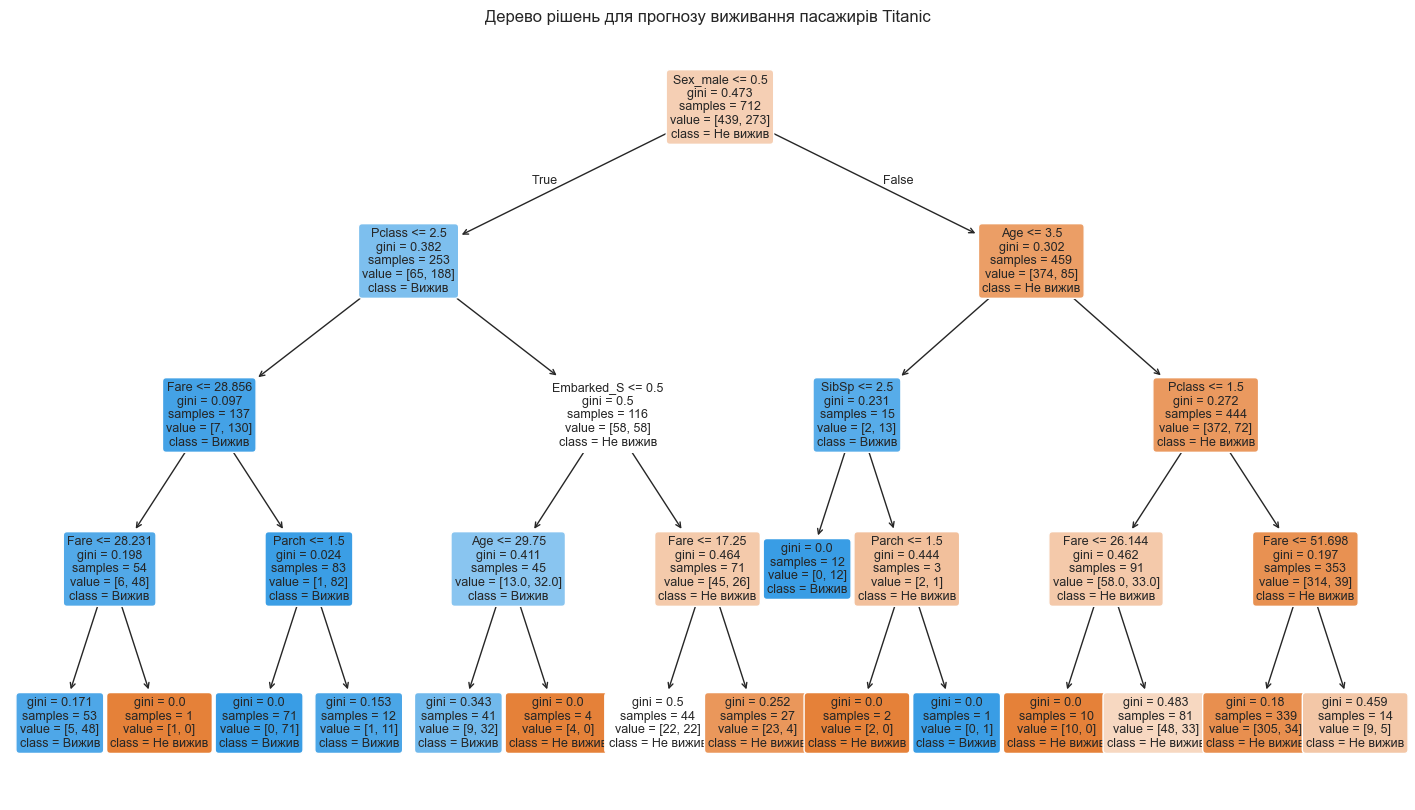

In [48]:
plt.figure(figsize=(18, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Не вижив", "Вижив"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Дерево рішень для прогнозу виживання пасажирів Titanic")
plt.show()

Візуалізуємо повну структуру дерева рішень глибиною 4. Кожен вузол містить умову розбиття, значення індексу Джині, кількість зразків та розподіл класів. Колір вузла відображає переважний клас: помаранчевий — "Вижив", блакитний — "Не вижив". Чим насиченіший колір — тим "чистіший" вузол.

Висновки

У ході виконання лабораторної роботи було побудовано класифікатор на основі дерева рішень для прогнозування виживання пасажирів Titanic.
Попередня обробка даних:
Датасет містив пропущені значення у колонках Age (177 пропусків) та Embarked (2 пропуски). Для заповнення Age використано медіану як стійку до викидів міру, для Embarked — моду. Категоріальні ознаки Sex і Embarked було перетворено у числовий формат за допомогою One-Hot Encoding.
Якість моделі:
Модель дерева рішень із глибиною 4 досягла точності ~79% на тестовій вибірці. При цьому:

- Precision для класу "Вижив" склав ~84% — модель рідко помилково відносить пасажирів до тих, що вижили
- Recall для класу "Не вижив" склав ~94% — модель дуже добре знаходить тих, хто не вижив
- F1-score для класу "Вижив" (~67%) помітно нижчий, ніж для класу "Не вижив" (~84%), що свідчить про труднощі з розпізнаванням меншого класу

Баланс класів:
Тестова вибірка є незбалансованою: ~61% — клас "Не вижив", ~39% — клас "Вижив". Через це метрики Precision, Recall та F1-score є більш інформативними, ніж Accuracy, яка може бути оманливо високою навіть при поганій роботі з меншим класом.
Важливість ознак:
Аналіз показав, що найбільший вплив на прогноз має:

- Sex_male (~57%) — стать є визначальним чинником виживання: жінки виживали значно частіше
- Pclass (~20%) — пасажири 1-го класу мали суттєво вищі шанси порівняно з 3-м
- Age (~11%) — молодший вік незначно підвищував шанси на виживання
- Fare (~6%) — вартість квитка корелює з класом каюти
- SibSp, Parch, Embarked — мають мінімальний вплив на прогноз

Структура дерева:
Перший розподільний вузол дерева використовує ознаку Sex_male, що підтверджує її домінуючу роль. Чоловіки переважно потрапляють у гілки з прогнозом "Не вижив", тоді як жінки — у гілки з вищою ймовірністю виживання. Подальші вузли уточнюють прогноз через клас каюти та вік пасажира.